In [1]:
from generatedata import generate_dataset
generate_dataset(1)

Generating sample 1/1
Lade Modell ...
Erzeuge ModelProcessor für Torque-Drive ...
Setze MocoTrack auf ...
Setze individuelle Tracking-Gewichte ...
Initialisiere Study ...
Starte Optimierung ...
Speichere Lösung im Speicher...
Fertig. Lösung wird übergeben.
Dataset saved to dataset.npz


In [2]:
import numpy as np

def set_axes_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    plot_radius = 0.5 * max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])

In [3]:
import matplotlib.pyplot as plt

def plot_gait_sample(data, ax=None, title=None):

    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')

    # split + remap axes (for intuitive visualization)
    xr, yr, zr = data[:,0], data[:,2], data[:,1]
    xl, yl, zl = data[:,3], data[:,5], data[:,4]

    ax.plot(xr, yr, zr, label="Right foot")
    ax.plot(xl, yl, zl, label="Left foot")

    ax.set_xlabel("Forward (x)")
    ax.set_ylabel("Lateral (y)")
    ax.set_zlabel("Vertical (z)")

    if title:
        ax.set_title(title)

    ax.legend()
    set_axes_equal(ax)

    return ax

tensor(0.8424)


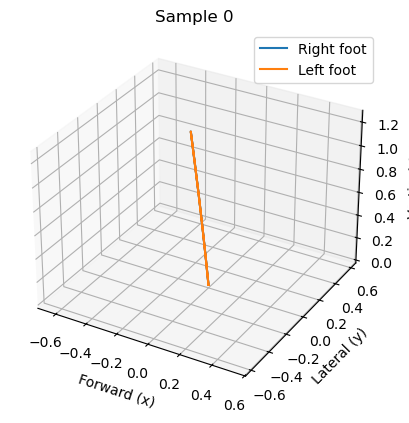

In [4]:
import torch
import numpy as np
data = np.load("dataset.npz")

foot = torch.tensor(data["foot"], dtype=torch.float32)
leg  = torch.tensor(data["leg"], dtype=torch.float32)

print(leg.squeeze())

for i in range(len(foot)):
    plot_gait_sample(foot[i].numpy(), title=f"Sample {i}")
    plt.show()